In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [4]:
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

print(y.value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [5]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(100000, 13)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80000, 13)
Testing: (20000, 13)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.82      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [9]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18300
           1       0.70      0.74      0.72      1700

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000



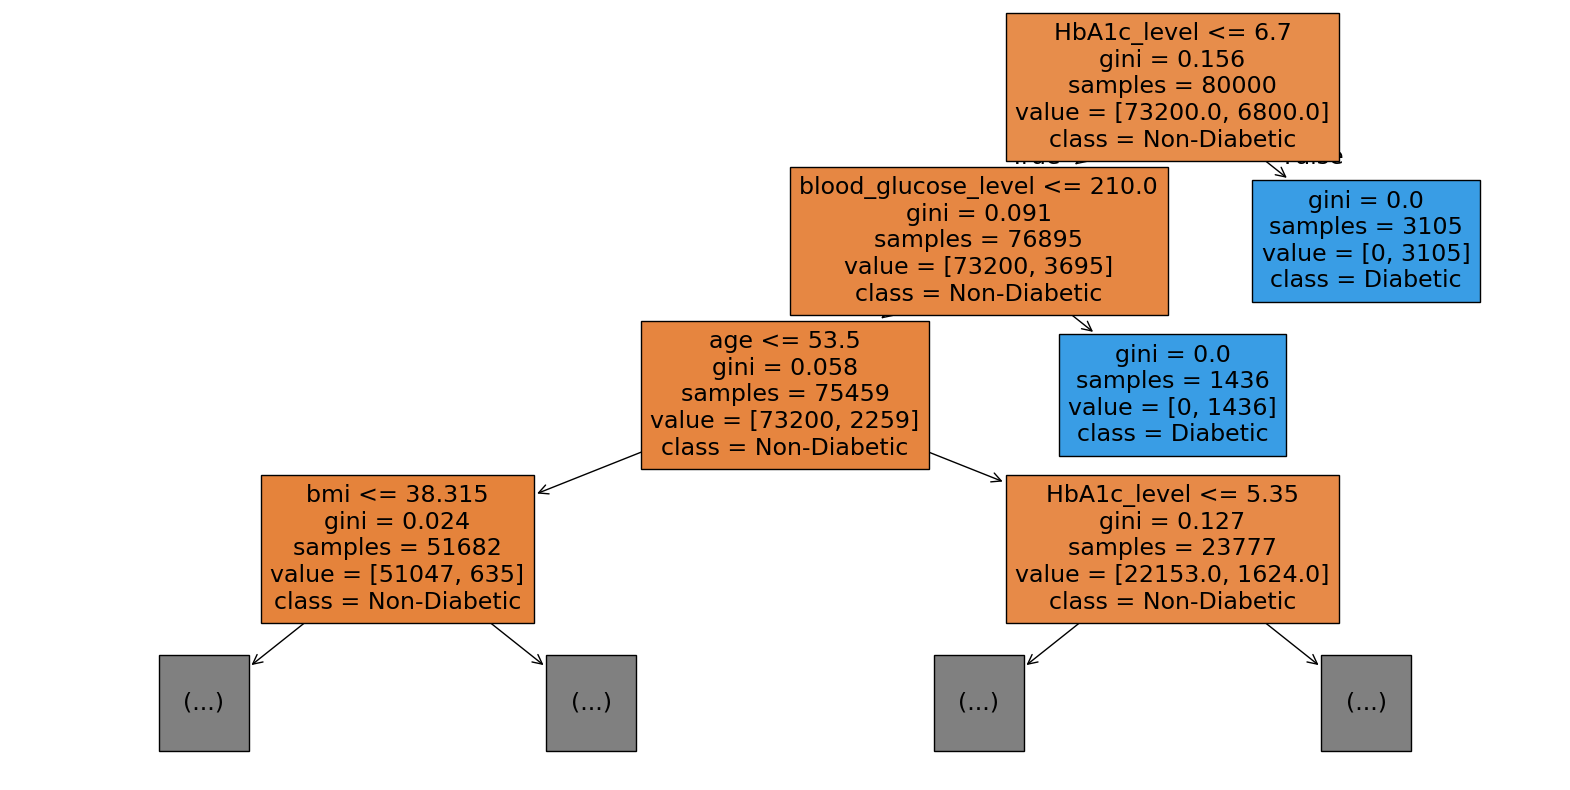

In [10]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    max_depth=3
)

plt.show()

In [11]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      0.20      0.33     18300
           1       0.10      1.00      0.19      1700

    accuracy                           0.27     20000
   macro avg       0.55      0.60      0.26     20000
weighted avg       0.92      0.27      0.32     20000



In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression   0.96050   0.859400  0.640000  0.733648
1        Decision Tree   0.95130   0.702793  0.740000  0.720917
2          Naive Bayes   0.26595   0.103585  0.997647  0.187683


In [13]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Performing Algorithm:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Performing Algorithm: Logistic Regression
F1 Score: 0.7336480107889414


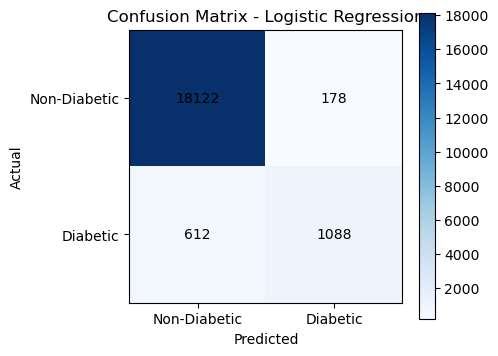

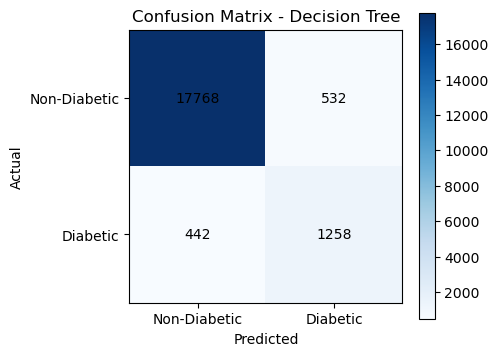

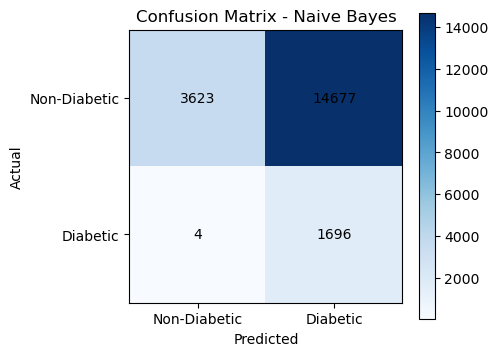

In [14]:
confusion_matrices = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Naive Bayes", y_pred_nb)
]

for name, prediction in confusion_matrices:
    cm = confusion_matrix(y_test, prediction)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")

    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
    plt.yticks([0, 1], ["Non-Diabetic", "Diabetic"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

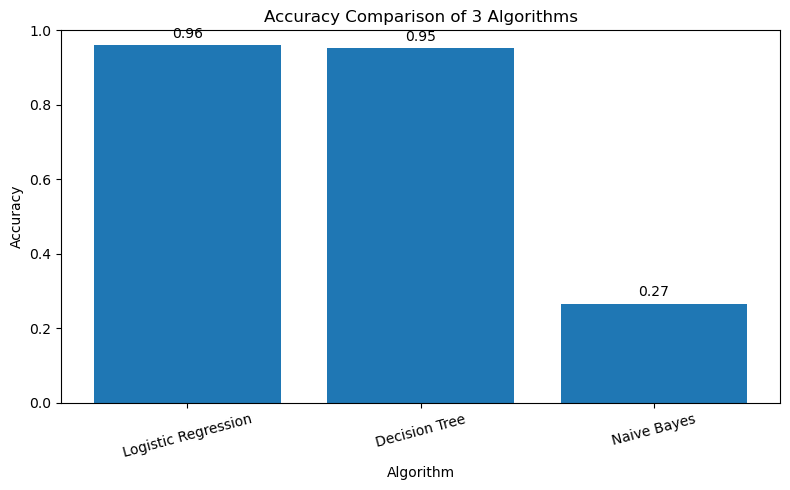

In [15]:
models = ["Logistic Regression", "Decision Tree", "Naive Bayes"]
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nb)
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison of 3 Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()